# Betaflight Controller Analysis Main File

Purpose:\
`Tool for analysing flight logs and tuning PID controllers for a quadcopter`

Authors:\
`Yuri Bianchi`\
`Janick Dort`\
`Dario Jurietti`

Supervisors:\
`Michael Peter`\
`Prof. Dr. Ruprecht Altenburger`

Date: 05.06.2026

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from py_lib.flight_data import FlightData
from py_lib.flight_analyzer import FlightAnalyzer
from py_lib.gyro_ctrl_tuning import GyroCtrlTuning
from py_lib.angle_ctrl_tuning import AngleCtrlTuning
from py_lib.pidtuninglib import header_info
from py_lib.plot_utils import PlotUtils


## General Setup

In [3]:
# Show legends in plots
do_insert_legends = True

# Create plot utility class
plotter = PlotUtils(do_insert_legends)

## Loading Data

In [4]:
log_folder = "logs"
flight_folder = "20260424"
log_name = "20260424_flipmini_2.TXT.csv"

file_path = Path(log_folder) / flight_folder / log_name

print(f"\nLoading flight log: {file_path}")

# Load flight data
df = FlightData(str(file_path))
df = df.get_data()

print(
    f"Data loaded: {len(df.time)} samples, "
    f"Ts_log = {df.Ts_log * 1000:.3f} ms"
)


Loading flight log: logs/20260424/20260424_flipmini_2.TXT.csv
Loading flight data...
Loaded from cache in 0.231s
Data loaded: 894433 samples, Ts_log = 0.500 ms


## Plot Flight Data

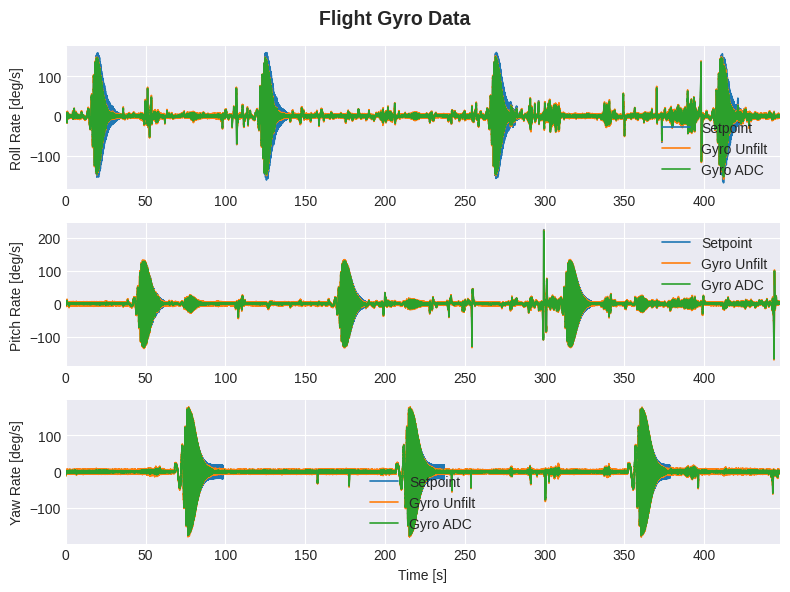

In [5]:
# Axis selection
# 0 = roll
# 1 = pitch
# 2 = yaw

roll, pitch, yaw = 0, 1, 2

# -------------------------------------------------------------------------
# Gyro and setpoint overview
# -------------------------------------------------------------------------

group1 = [
    {
        "idx": np.array([
            df.ind.setpoint[roll],
            df.ind.gyroUnfilt[roll],
            df.ind.gyroADC[roll],
        ]),
        "ylabel": "Roll Rate [deg/s]",
        "legend": ["Setpoint", "Gyro Unfilt", "Gyro ADC"],
    },
    {
        "idx": np.array([
            df.ind.setpoint[pitch],
            df.ind.gyroUnfilt[pitch],
            df.ind.gyroADC[pitch],
        ]),
        "ylabel": "Pitch Rate [deg/s]",
        "legend": ["Setpoint", "Gyro Unfilt", "Gyro ADC"],
    },
    {
        "idx": np.array([
            df.ind.setpoint[yaw],
            df.ind.gyroUnfilt[yaw],
            df.ind.gyroADC[yaw],
        ]),
        "ylabel": "Yaw Rate [deg/s]",
        "legend": ["Setpoint", "Gyro Unfilt", "Gyro ADC"],
    },
]

plotter.plot_flight_data(df, group1, "Flight Gyro Data")


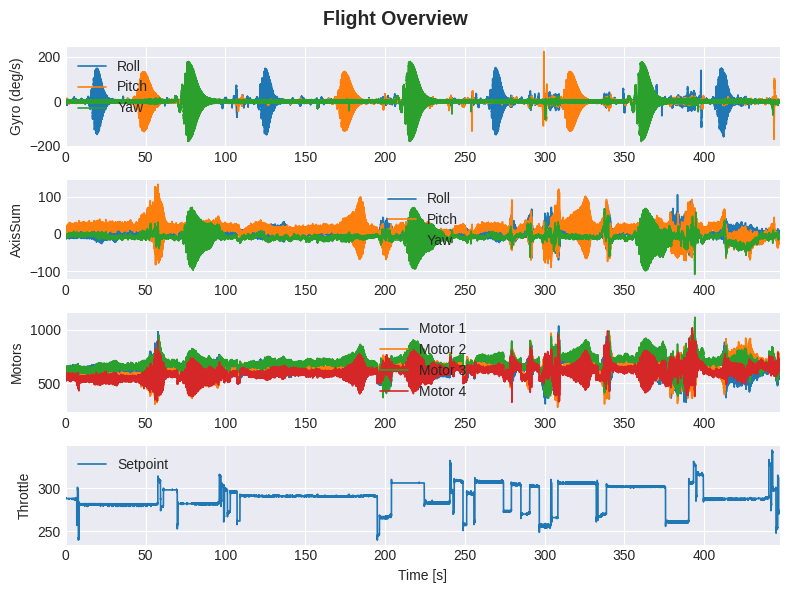

In [6]:
group2 = [
    {
        "idx": df.ind.gyroUnfilt,
        "ylabel": "Gyro (deg/s)",
        "legend": ["Roll", "Pitch", "Yaw"],
    },
    {
        "idx": df.ind.axisSum,
        "ylabel": "AxisSum",
        "legend": ["Roll", "Pitch", "Yaw"],
    },
    {
        "idx": df.ind.motor,
        "ylabel": "Motors",
        "legend": ["Motor 1", "Motor 2", "Motor 3", "Motor 4"],
    },
    {
        "idx": np.array([df.ind.setpoint[3]]),
        "ylabel": "Throttle",
        "legend": ["Setpoint"],
    },
]

plotter.plot_flight_data(df, group2, "Flight Overview")

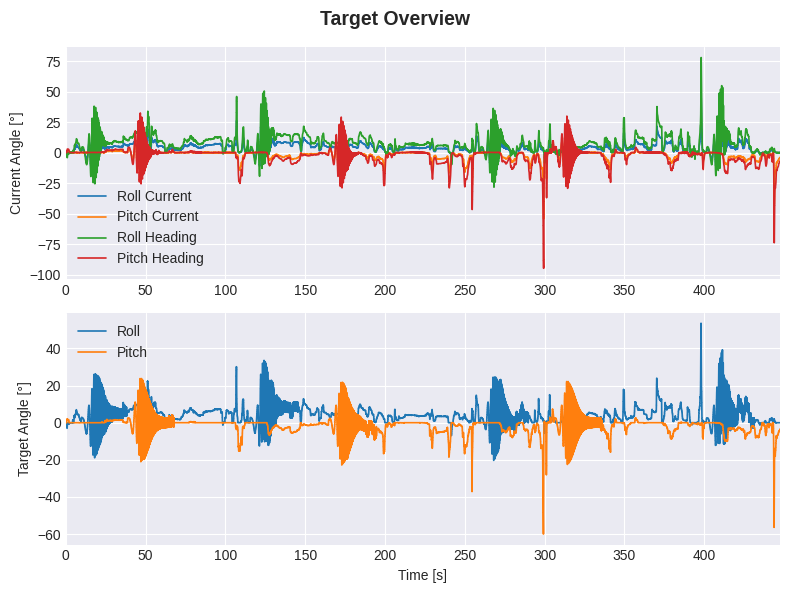

In [7]:
group3 = [
    {
        "idx": np.array([
            df.ind.currentAngle[roll],
            df.ind.currentAngle[pitch],
            df.ind.heading[roll],
            df.ind.heading[pitch],
        ]),
        "ylabel": "Current Angle [°]",
        "legend": [
            "Roll Current",
            "Pitch Current",
            "Roll Heading",
            "Pitch Heading",
        ],
    },
    {
        "idx": df.ind.angleTarget[0:2],
        "ylabel": "Target Angle [°]",
        "legend": ["Roll", "Pitch"],
    },
]

plotter.plot_flight_data(df, group3, "Target Overview")

## Plot evaluation time

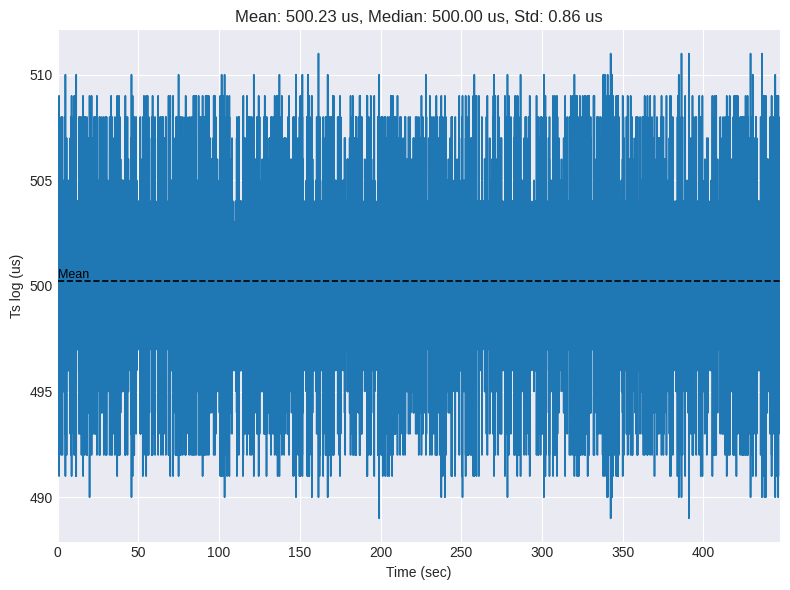

In [8]:
plotter.plot_eval_time(df.time)

## Transfer Function Estimation

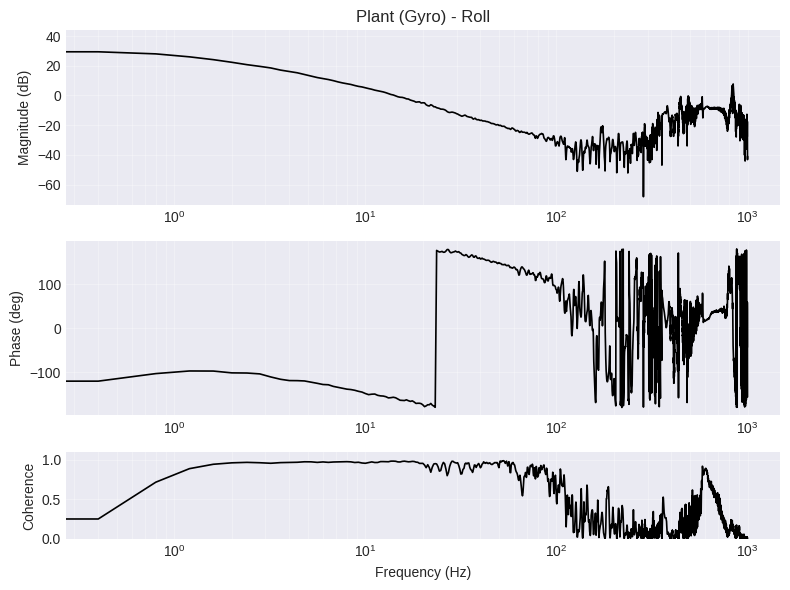

In [10]:
# Create gyro tuning object
gyro_tuning = GyroCtrlTuning(
    df.data,
    df.ind,
    df.Ts_log,
    df.para,
    df.Ts_cntr,
)

# -------------------------------------------------------------------------
# Parameters for spectral estimation
# -------------------------------------------------------------------------

# Window length for spectral estimation
resolution_factor_tf = 2.5

# Overlap factor for Welch estimation
overlap_tf = 0.9

# Calculate transfer functions
gyro_tuning = gyro_tuning.calculate_transfer_func(
    resolution_factor_tf,
    overlap_tf,
)

# Plot estimated plant bode plot
plotter.plot_bode_plant(gyro_tuning, roll, "Gyro")


## Flight Analyzer

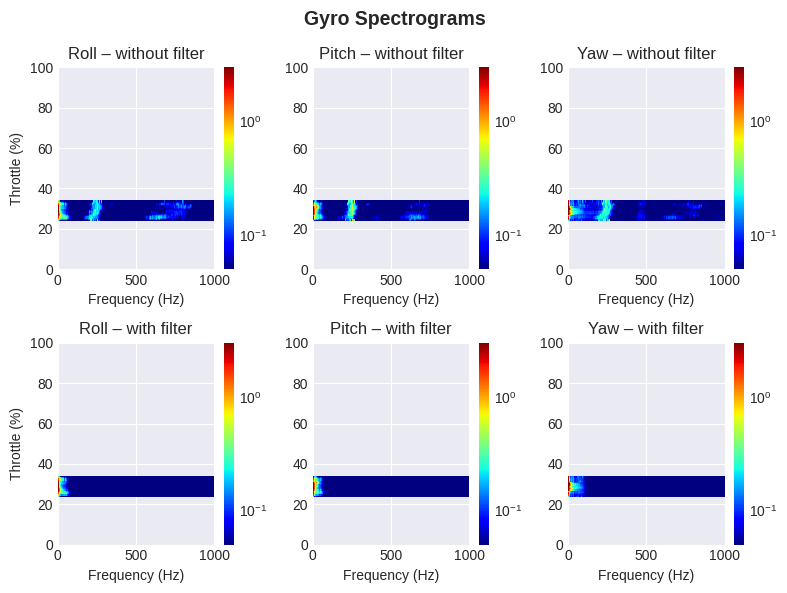

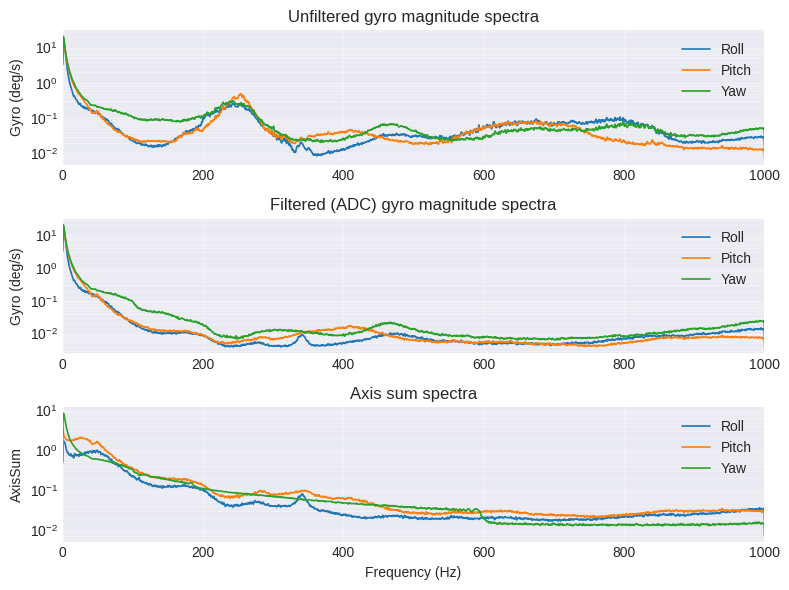

In [18]:
# Create analyzer object
analysis_flight = FlightAnalyzer(
    df.data,
    df.ind,
    df.Ts_log,
)

# -------------------------------------------------------------------------
# Spectra calculation
# -------------------------------------------------------------------------

# Window length for spectral estimation
resolution_factor_spectra = 2.0

# Overlap factor for Welch estimation
overlap_spectra = 0.9

analysis_flight = analysis_flight.calculate_spectra(
    resolution_factor_spectra,
    overlap_spectra,
)

# -------------------------------------------------------------------------
# Spectrogram calculation
# -------------------------------------------------------------------------

# Window length for spectrogram estimation
resolution_factor_spectrogram = 2.0

# Overlap factor for spectrogram estimation
overlap_spectrogram = 0.9

analysis_flight = analysis_flight.calculate_spectrogram(
    resolution_factor_spectrogram,
    overlap_spectrogram,
)

# -------------------------------------------------------------------------
# Plot spectral analysis
# -------------------------------------------------------------------------

plotter.plot_spectrogram(analysis_flight, 3)
plotter.plot_gyro_spectra(analysis_flight)

## Gyro Tuning

Calculation time: 0.089s
Tuning data calculation time: 0.467s


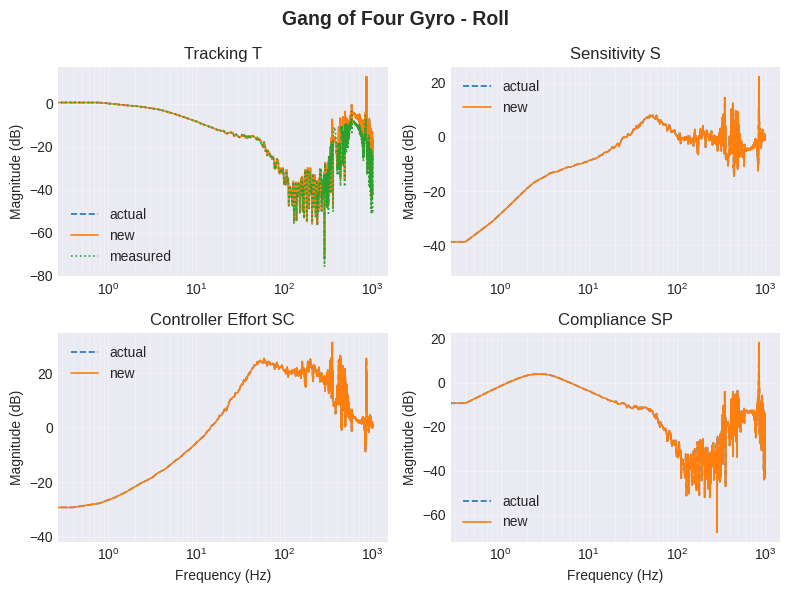

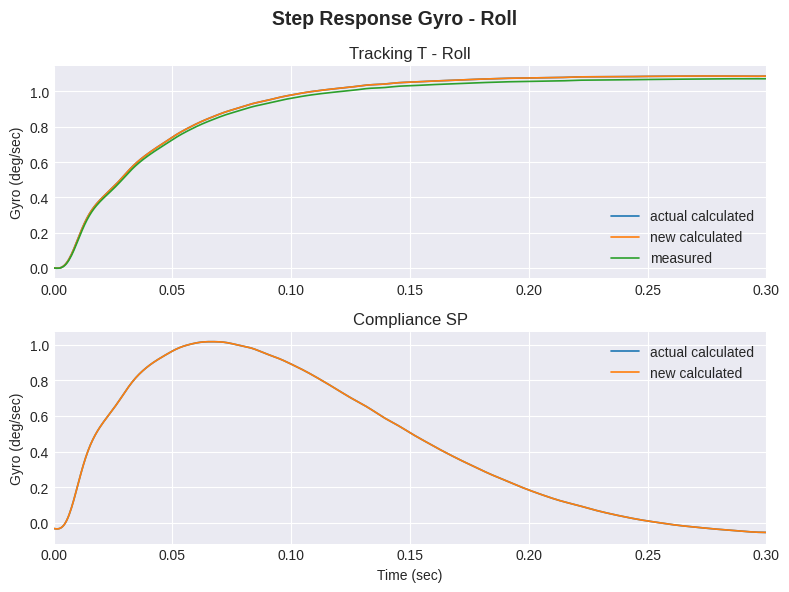

In [17]:
# =========================================================================
# Selection:
# 0 = roll
# 1 = pitch
# 2 = yaw
# =========================================================================

ind_ax = 0

# I-term relax compensation on/off
do_compensate_iterm = True

# Use same parameters as in original flight
default_parameters_gyro = True

# Create copy of parameters
para_new = df.para.make_copy()

# =========================================================================
# Configure filters to match Betaflight settings
# =========================================================================
# All frequencies are in Hz
#
# Filter types:
#   0 = PT1 (First order lowpass)
#   1 = BIQUAD (Second order)
#   2 = PT2 (Second order lowpass)
#   3 = PT3 (Third order lowpass)
# =========================================================================

# -------------------------------------------------------------------------
# Gyro filters
# -------------------------------------------------------------------------

para_new.data["gyro_lpf"] = "0"
para_new.data["gyro_lowpass_hz"] = "0"
para_new.data["gyro_soft_type"] = "0"

# Dynamic gyro LPF overwrites gyro_lowpass_hz
para_new.data["gyro_lowpass_dyn_hz"] = "0,0"

# Gyro LPF2
para_new.data["gyro_lowpass2_hz"] = "800"
para_new.data["gyro_soft2_type"] = "0"

# Gyro notch filters
para_new.data["gyro_notch_hz"] = "0,0"
para_new.data["gyro_notch_cutoff"] = "0,0"

# -------------------------------------------------------------------------
# D-term filters
# -------------------------------------------------------------------------

para_new.data["dterm_lpf_hz"] = "0"
para_new.data["dterm_filter_type"] = "0"

# Dynamic dterm LPF overwrites dterm_lpf_hz
para_new.data["dterm_lpf_dyn_hz"] = "0,0"

para_new.data["dterm_lpf2_hz"] = "140"
para_new.data["dterm_filter2_type"] = "3"

# D-term notch filter
para_new.data["dterm_notch_hz"] = "0"
para_new.data["dterm_notch_cutoff"] = "0"

# Yaw lowpass filter
para_new.data["yaw_lpf_hz"] = "200"

# =========================================================================
# Tune your PID values here
# =========================================================================
# Higher P:
#   Faster response but possible oscillations
#
# Higher I:
#   Better steady-state tracking but slower response
#
# Higher D:
#   Better damping but more noise sensitive
# =========================================================================

if ind_ax == 0:
    # Roll PID values
    # Default: P=45, I=80, D=30

    P_new = 30
    I_new = 70
    D_new = 30

elif ind_ax == 1:
    # Pitch PID values
    # Default: P=47, I=84, D=34

    P_new = 49
    I_new = 96
    D_new = 35

else:
    # Yaw PID values
    # Default: P=45, I=80, D=0

    P_new = 45
    I_new = 86
    D_new = 1

# Calculate new controller
gyro_tuning = gyro_tuning.calculate_new_controller(
    ind_ax,
    P_new,
    I_new,
    D_new,
    default_parameters_gyro,
    para_new,
)

# Calculate tuning data
gyro_tuning = gyro_tuning.get_tuning_data(
    do_compensate_iterm
)

# -------------------------------------------------------------------------
# Plot tuning evaluation
# -------------------------------------------------------------------------

plotter.plot_gang_of_four(gyro_tuning, "Gyro")

plotter.plot_step_compliance(
        gyro_tuning,
        "Gyro",
        "Gyro (deg/sec)",
    )


## Angle Tuning

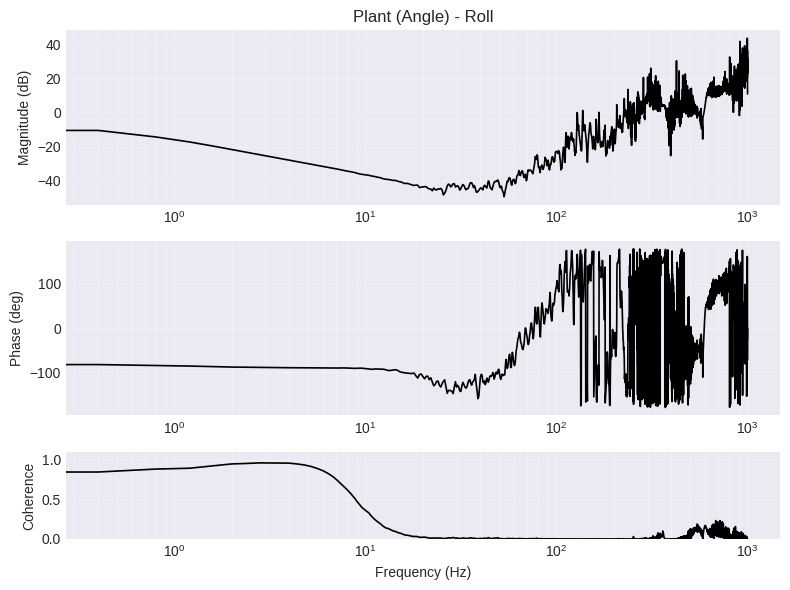

In [ ]:

# Create angle tuning object
angle_tuning = AngleCtrlTuning(
    df.data,
    df.ind,
    df.Ts_log,
    df.para,
    df.Ts_cntr,
    gyro_tuning,
)

# Calculate angle transfer functions
angle_tuning = angle_tuning.calculate_angle_trans(
    resolution_factor_tf,
    overlap_tf,
)

# Plot angle plant bode plot
plotter.plot_bode_plant(
    angle_tuning,
    roll,
    "Angle",
)

## Angle controller tuning

   used P parameter Angle Control are:
      P: 65
   new P parameter Angle Control are:
      P: 120


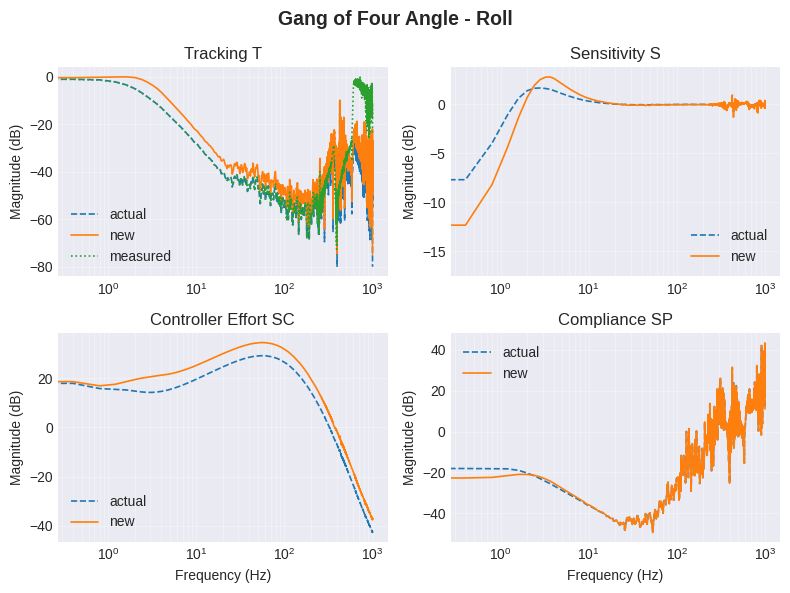

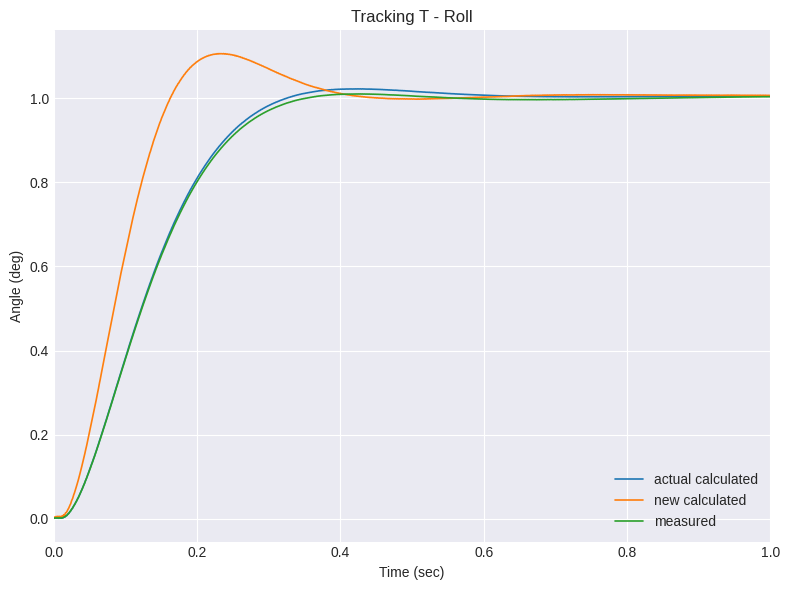

In [ ]:
# Use same parameters as original flight
default_parameters_angle = False

# PT3 Angle Control
P_angle = 120

# Calculate new controller
angle_tuning = angle_tuning.calculate_new_controller(
    ind_ax,
    P_angle,
    default_parameters_angle,
)

# Calculate tuning data
angle_tuning = angle_tuning.get_tuning_data()

# -------------------------------------------------------------------------
# Plot tuning evaluation
# -------------------------------------------------------------------------

plotter.plot_gang_of_four(
    angle_tuning,
    "Angle",
)
plotter.plot_step_response(
        angle_tuning,
        "Angle",
        "Angle (deg)",
    )